# Fisheries Conflict Analysis

## Load packages and data

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
import random
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance
import shap
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import MinMaxScaler

C:\Users\ryans\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load WWF data set
df = pd.read_csv('combined_data.csv')

# Preview the data
df.head()

,source_file,event_id,date,year,country,region,Location,latitude,longitude,loc_accuracy,...,matched_sst_lat,matched_sst_lon,sst_degC,sst_search_radius_deg,sst_distance_km,sst_month,sst_historical_same_month_mean_degC,sst_diff_same_month_degC,month,soi
0,Oceania_No_AUS_NZL_Final,24328612817,2011-12-01 00:00:00,2011,American Samoa,Oceania,"Pago Pago, capital of American Samoa.",-14.27806,-170.70250,Town,...,-14.0,190.0,28.764431,2.0,81.815167,12,28.586988,0.177443,12,2.5
1,Oceania_No_AUS_NZL_Final,24359251958,2011-10-12 00:00:00,2011,French Polynesia,Oceania,"Port of Papeete, French Polynesia.",-17.53600,-149.58200,Town,...,-18.0,210.0,26.528063,2.0,67.978914,10,26.232477,0.295586,10,0.8
2,Oceania_No_AUS_NZL_Final,24349703891,2011-08-01 00:00:00,2011,Guam,Oceania,"Hotel Wharf, Port Authority of Guam.",13.46000,144.66500,Town,...,14.0,144.0,29.538723,2.0,93.622497,8,29.193617,0.345106,8,0.4
3,Oceania_No_AUS_NZL_Final,24327648295,2011-11-10 00:00:00,2011,Guam,Oceania,"Agana and Agat Marinas, Guam.",13.47567,144.74886,Town,...,14.0,144.0,29.095762,2.0,99.709164,11,28.614426,0.481337,11,1.1
4,Oceania_No_AUS_NZL_Final,24359264846,2011-10-13 00:00:00,2011,High Seas,Oceania,"Pacific high seas, near several Pacific island...",-14.47300,178.01800,International,...,-14.0,178.0,28.260935,2.0,52.630968,10,27.538280,0.722654,10,0.8


## Exploratory Data Analysis

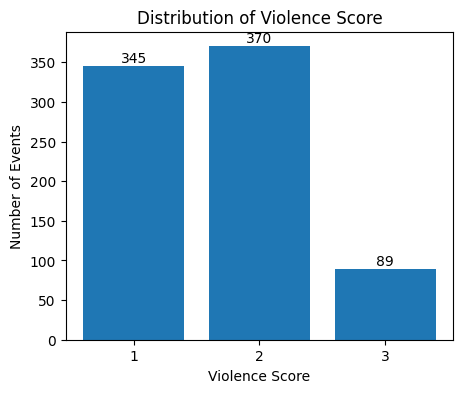

In [4]:
# Distribution of violence_score
violence_counts = (
    df["violence_score"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(5,4))
plt.bar(
    violence_counts.index.astype(str),
    violence_counts.values
)

plt.title("Distribution of Violence Score")
plt.xlabel("Violence Score")
plt.ylabel("Number of Events")

for i, count in enumerate(violence_counts.values):
    plt.text(i, count + 5, str(count), ha="center")

plt.show()

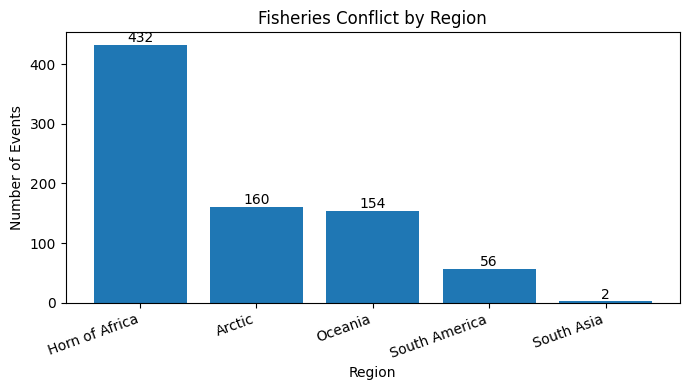

In [5]:
# Distribution of Regions
region_counts = df["region"].value_counts()

plt.figure(figsize=(7,4))
plt.bar(
    region_counts.index,
    region_counts.values
)

plt.title("Fisheries Conflict by Region")
plt.xlabel("Region")
plt.ylabel("Number of Events")
plt.xticks(rotation=20, ha="right")

for i, count in enumerate(region_counts.values):
    plt.text(i, count + 5, str(count), ha="center")

plt.tight_layout()
plt.show()

In [6]:
# Count of violence_score by region
pd.crosstab(df['region'], df['violence_score'])

violence_score,1,2,3
region,,,
Arctic,124,36,0
Horn of Africa,129,227,76
Oceania,84,61,9
South America,8,44,4
South Asia,0,2,0


## Data Analysis & Modeling

In [ ]:
# Columns of interest for analysis
data = df[[
    "region",
    "WeakGov", 
    "FishPop", 
    "EcoChngeOther", 
    "GroundsLim", 
    "ForeignFisher", 
    "IllegalFishing", 
    "IncrEfficiency", 
    "OpsScales",
    "Markets",
    "Poverty",
    "FoodInsecurity",
    "Marginalization",
    "StratLoc",
    "MaritimeCrime",
    "sst_diff_same_month_degC",
    'soi',
    "violence_score"
]]


In [27]:
# Filter by region
def regional_filtering(data, region_string = None):
    if region_string is None:
        filtered = data
    elif region_string not in data['region'].values:
        valid_regions = data['region'].unique().tolist()
        raise ValueError(f"{region_string} is not a valid region in the dataset. These are the available options: {valid_regions}.")
    else:
        filtered = data[data['region'] == region_string]
    return filtered

filtered = regional_filtering(data)

In [28]:
# Split data into training and testing groups
#Input: filtered data with 'region' variable from regional_filtering
def split_data(data):
    data2 = data.drop(columns = ['region'])
    X = data2.loc[:, data2.columns != 'violence_score']
    y = data2['violence_score']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, stratify = y, random_state=42)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = split_data(data)
X_test


,WeakGov,FishPop,EcoChngeOther,GroundsLim,ForeignFisher,IllegalFishing,IncrEfficiency,OpsScales,Markets,Poverty,FoodInsecurity,Marginalization,StratLoc,MaritimeCrime,sst_diff_same_month_degC,soi
741,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0.021139,0.4
585,1,0,0,1,1,1,0,0,0,0,0,0,0,1,1.509621,-1.5
489,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.477745,-0.7
515,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0.189035,1.8
747,1,1,0,1,1,1,0,0,0,0,0,0,0,1,0.069511,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
323,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0.672779,-0.4
294,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1.262018,0.4
412,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1.023708,-0.1
670,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0.685354,-1.4


In [38]:
def models(X_train, y_train):
    feature_names = X_train.columns 

    model_params = [
        {
            'name': 'Logistic Regression',
            'estimator': LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                class_weight = 'balanced',
                random_state=42,
                max_iter = 6000
            ),
            'param_grid': {
                'l1_ratio': np.linspace(0, 1, 5),
                'C': np.linspace(.001, 10, 7) # smaller value = stronger regularization
            }
        },

        {
            'name': 'Random Forest',
            'estimator': RandomForestClassifier(class_weight = 'balanced', max_features= 8, random_state=42),
            'param_grid': {
                'n_estimators': np.linspace(20, 250, 25).astype(int),
                'max_depth': [4, 7],
                'min_samples_split': [3, 5]
            }
        }
    ]

    cv_strategy = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42) 
    scoring = {
        'pr_auc': 'average_precision',
        'accuracy': 'accuracy'}

    results = []

    for item in model_params:
        grid = GridSearchCV(
            item['estimator'],
            item['param_grid'],
            cv=cv_strategy,
            scoring=scoring,
            refit = 'pr_auc',
            n_jobs = -1
        )

        grid.fit(X_train, y_train)

        model_name = item['name']

        
        for i, params in enumerate(grid.cv_results_['params']):

            # fit model for each parameter set
            temp_model = grid.estimator.set_params(**params)
            temp_model.fit(X_train, y_train)

            # feature selection per model
            if hasattr(temp_model, "coef_"): #for log reg
                coef = temp_model.coef_
                mask = np.any(np.abs(coef) > 1e-3, axis=0)

            elif hasattr(temp_model, "feature_importances_"): # for random forest
                importances = temp_model.feature_importances_
                mask = importances > 0

            else:
                mask = np.ones(len(feature_names), dtype=bool)

            selected_features = feature_names[mask]
            non_zero = np.sum(mask)

            results.append({
                'model': item['name'],
                'params': params,
                'training_data_accuracy': grid.cv_results_['mean_test_accuracy'][i],
                'pr_auc': grid.cv_results_['mean_test_pr_auc'][i],
                'non_zero_features': non_zero,
                'selected_features': list(selected_features),
                'mean_fit_time': grid.cv_results_['mean_fit_time'][i]
            })

    results_df = pd.DataFrame(results)

    # sort highest accuracy to lowest
    results_df = results_df.sort_values('training_data_accuracy', ascending=False).reset_index(drop=True)
    
    best_models = (
                    results_df
                    .sort_values('training_data_accuracy', ascending=False)
                    .groupby('model', as_index=False)
                    .first()
                    )

    return results_df, best_models

results_df, best_models = models(X_train, y_train)

In [44]:
best_models


,model,params,training_data_accuracy,pr_auc,non_zero_features,selected_features,mean_fit_time
0,Logistic Regression,"{'C': 1.6675, 'l1_ratio': 0.25}",0.600339,0.562177,16,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.033092
1,Random Forest,"{'max_depth': 7, 'min_samples_split': 5, 'n_es...",0.664038,0.623804,16,"[WeakGov, FishPop, EcoChngeOther, GroundsLim, ...",0.407068


In [54]:
# Assess performance with best models on test data
def assessment(best_models, X_train, y_train, X_test, y_test):
    #loop through each row of best_models
    for index, row in best_models.iterrows():
        model = row['model']
        params = row['params'] #dict

        # train model again with 'best' params and assess model on test data
        if model == 'Logistic Regression':
            model = LogisticRegression(**row['params'],
                                    penalty='elasticnet',
                                    solver='saga',
                                    class_weight = 'balanced',
                                    random_state=42,
                                    max_iter = 4000)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            # y_probability = pd.DataFrame(model.predict_proba(X_test), y_test) # compare violence_score to likelihood datapoint is each conflict type
        
            
            # Classification report
            display('Logistic Regression Results:')
            # print(classification_report(y_test, y_pred)) 
            

            #  df of intercept, coefs, and odds_ratio with variable names
            coef_df = pd.DataFrame(
                np.vstack([model.intercept_, model.coef_.T]),
                index=["Intercept"] + list(model.feature_names_in_),
                ).reset_index()
            coef_df.columns = ["Variable", "response_1_coef", "response_2_coef", "response_3_coef"]
            coef_df["odds_ratio_1"] = np.exp(coef_df["response_1_coef"])
            coef_df["odds_ratio_2"] = np.exp(coef_df["response_2_coef"])
            coef_df["odds_ratio_3"] = np.exp(coef_df["response_3_coef"])
            ordered_columns = [
                        "Variable",
                        "response_1_coef",
                        "odds_ratio_1",
                        "response_2_coef",
                        "odds_ratio_2",
                        "response_3_coef",
                        "odds_ratio_3",
                    ]
            coef_df = coef_df[ordered_columns]
            display(coef_df)


        if model == 'Random Forest':
            model = RandomForestClassifier(**row['params'], class_weight = 'balanced', max_features= 8, random_state=42)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        
            display("Random Forest Results:")
            # # feature importance
            # importances = model.feature_importances_
            # feature_names = model.feature_names_in_
            # feature_imp_df = pd.DataFrame({'Feature': feature_names, 
            #                                'Gini Importance': importances
            #                                }).sort_values('Gini Importance', ascending=False)
            # display(feature_imp_df)

            # plt.figure()
            # plt.barh(feature_imp_df['Feature'], feature_imp_df['Gini Importance'])
            # plt.xlabel('Gini Importance')
            # plt.title('Feature Importance - Gini Importance')
            # plt.gca().invert_yaxis() # feature with largest importance on top
            # plt.show()

            # Permutation Importance
            feature_names = model.feature_names_in_
            perm = permutation_importance(
                model,
                X_test,
                y_test,
                n_repeats=20,
                random_state=42,
                scoring="average_precision"
            )

            perm_df = pd.DataFrame({
                "Feature": feature_names,
                "Permutation Importance": perm.importances_mean,
                "Std": perm.importances_std
            }).sort_values(
                "Permutation Importance",
                ascending=False
            )

            display(perm_df)

            plt.figure(figsize=(8,5))
            plt.barh(
                perm_df["Feature"],
                perm_df["Permutation Importance"],
                xerr=perm_df["Std"]
            )
            plt.xlabel("Decrease in Average Precision")
            plt.title("Permutation Feature Importance")
            plt.gca().invert_yaxis()
            plt.show()

            #Shapley additive explanations
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)

            colors = ListedColormap(["#0A2540", "#4A90E2", "#A5C7E6"])
            shap.summary_plot(shap_values, 
                              X_test, 
                              plot_type="bar", 
                              color = colors, 
                              feature_names = feature_names,
                              class_names = ['low-intensity', 'medium-intensity', 'high-intensity'], 
                              show = False)
            plt.title("Feature Importance - SHAP")
            plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)")
            plt.ylabel("Features")
        

        # Classification report
        print(classification_report(y_test, y_pred)) 

        # Confusion matrix 
        cm = confusion_matrix(y_test, y_pred, labels=[1, 2, 3])
        plt.figure()
        disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = [1, 2, 3])
        disp.plot(cmap = plt.cm.Blues)
        plt.title(f"Confusion Matrix: {row['model']}")
        plt.xlabel('Prediction')
        plt.ylabel('Actual')
        plt.show()

   

'Logistic Regression Results:'

,Variable,response_1_coef,odds_ratio_1,response_2_coef,odds_ratio_2,response_3_coef,odds_ratio_3
0,Intercept,0.687406,1.988551,1.060474,2.887739,-1.747880,0.174143
1,WeakGov,0.500030,1.648770,-0.702258,0.495466,0.202228,1.224127
2,FishPop,0.438429,1.550270,0.256313,1.292157,-0.694742,0.499203
3,EcoChngeOther,1.679116,5.360813,-0.744266,0.475083,-0.934850,0.392645
4,GroundsLim,0.373133,1.452278,-0.479043,0.619376,0.105910,1.111721
5,ForeignFisher,-0.462292,0.629839,0.273934,1.315128,0.188358,1.207266
6,IllegalFishing,-0.319164,0.726756,0.402221,1.495141,-0.083057,0.920299
7,IncrEfficiency,0.327353,1.387291,-0.310665,0.732959,-0.016688,0.983451
8,OpsScales,0.570987,1.770012,-0.147233,0.863093,-0.423754,0.654585
9,Markets,2.194859,8.978737,-1.213706,0.297094,-0.981153,0.374879


              precision    recall  f1-score   support

           1       0.61      0.42      0.50        26
           2       0.76      0.57      0.65        46
           3       0.26      0.60      0.36        15

    accuracy                           0.53        87
   macro avg       0.54      0.53      0.50        87
weighted avg       0.63      0.53      0.56        87



<Figure size 640x480 with 0 Axes>

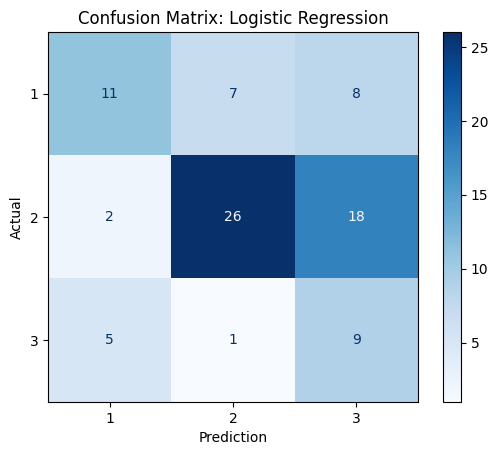

'Random Forest Results:'

,Feature,Permutation Importance,Std
2,EcoChngeOther,0.055813,0.029198
12,StratLoc,0.048323,0.014940
0,WeakGov,0.048236,0.026999
13,MaritimeCrime,0.036035,0.012537
4,ForeignFisher,0.020694,0.016392
1,FishPop,0.012936,0.012447
3,GroundsLim,0.003840,0.006373
9,Poverty,0.000787,0.005191
8,Markets,0.000000,0.000000
11,Marginalization,-0.000442,0.011952


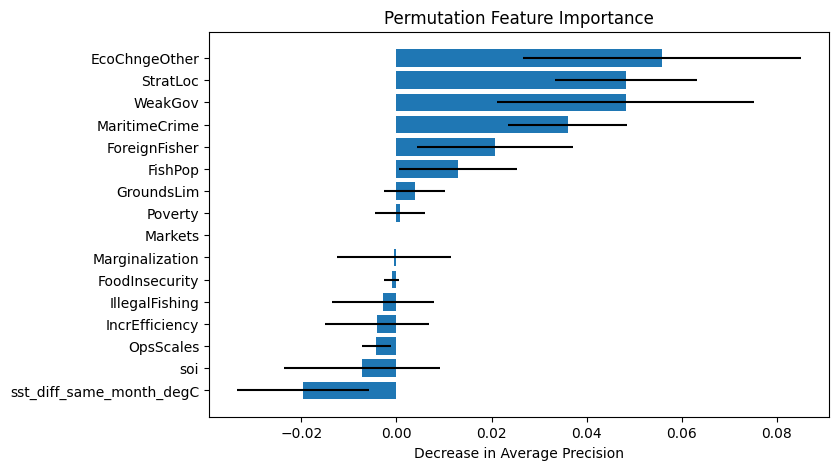

              precision    recall  f1-score   support

           1       0.56      0.35      0.43        26
           2       0.67      0.70      0.68        46
           3       0.22      0.33      0.26        15

    accuracy                           0.53        87
   macro avg       0.48      0.46      0.46        87
weighted avg       0.56      0.53      0.53        87



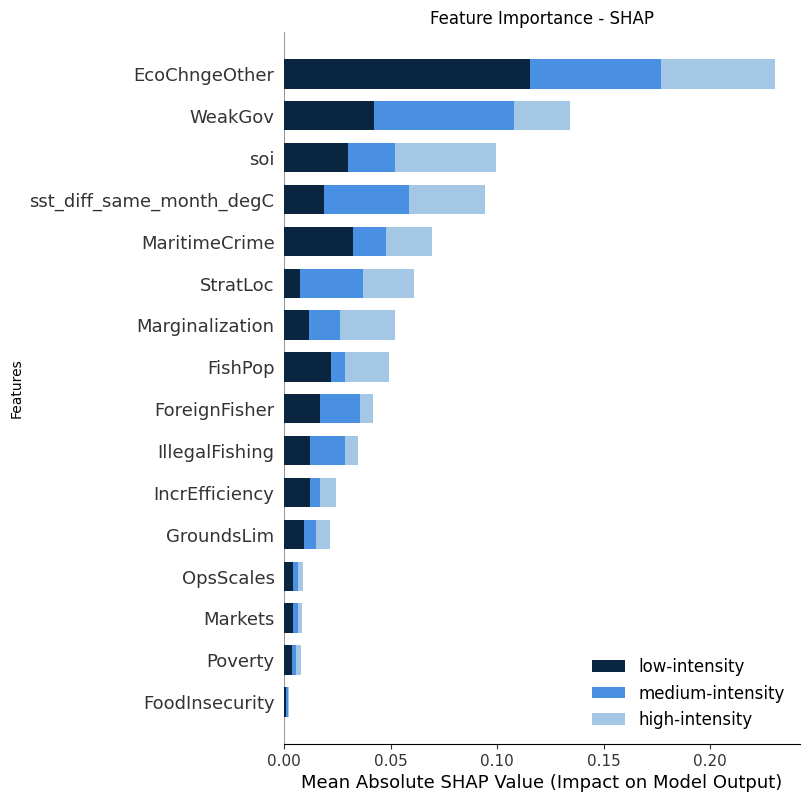

<Figure size 640x480 with 0 Axes>

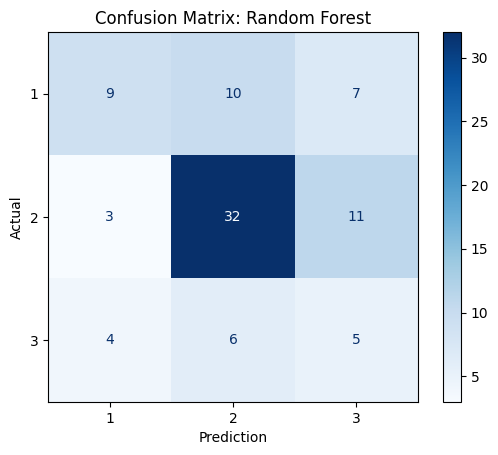

In [ ]:
# Run all analysis
def analysis(data, region = None):
    filtered_data = regional_filtering(data, region)
    X_train, X_test, y_train, y_test = split_data(filtered_data)
    scaler = MinMaxScaler()
    continuous_cols = ["sst_diff_same_month_degC", 'soi']
    X_train_scaled_df = X_train.copy()
    X_test_scaled_df = X_test.copy()
    X_train_scaled_df[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
    X_test_scaled_df[continuous_cols] = scaler.transform(X_test[continuous_cols])

    results_df, best_models = models(X_train_scaled_df, y_train)
    assessment(best_models, X_train_scaled_df, y_train, X_test_scaled_df, y_test)



In [ ]:
# Run analysis
#   can add a string for the region to evaluate
analysis(data, "Horn of Africa")

## References
- Creating a correlation matrix: https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/
- different solvers explanation: https://stackoverflow.com/questions/38640109/logistic-regression-python-solvers-definitions
- Logistic regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Confusion Matrix chart: https://www.geeksforgeeks.org/machine-learning/confusion-matrix-machine-learning/
- Feature Importance chart: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/
- NOAA Extended Reconstructed SST V5: https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html